# Analysis of Study Data

Prolific participants only. Auto-detects the export timestamp from CSV files in this directory.


## Setup

In [1]:
# Install required packages (uncomment and run if needed)
#!pip install pandas matplotlib seaborn ipywidgets

# Note: json, glob, os, and html are built-in Python modules — no installation needed


In [2]:
import glob
import json
import os
from html import escape
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

# Ensure working directory is the notebook's directory (VS Code sets cwd to repo root)
if not glob.glob('moderation_sessions_export_*.csv'):
    _candidates = sorted(glob.glob('data-exports/*/moderation_sessions_export_*.csv'))
    if _candidates:
        os.chdir(os.path.dirname(_candidates[-1]))
print(f"Working directory: {os.getcwd()}")

Working directory: /Users/johndriscoll/ParentalControl/DSL-kidsgpt-open-webui/data-exports/20260314_082139


### Data Loading and Filtering


In [3]:
# ── Configuration ──────────────────────────────────────────────────────────────
# Set DEV_MODE = True to skip Prolific PID filtering (useful for dev/test data)
DEV_MODE = True

# Auto-detect export timestamp from CSV files in this directory
_mod_files = sorted(glob.glob('moderation_sessions_export_*.csv'))
if not _mod_files:
    raise FileNotFoundError(
        "No moderation_sessions_export_*.csv found in current directory. "
        "Run the export script first, then open the notebook from its export folder."
    )

EXPORT_TIMESTAMP = _mod_files[-1].replace('moderation_sessions_export_', '').replace('.csv', '')
print(f"Detected export timestamp: {EXPORT_TIMESTAMP}")
print(f"DEV_MODE: {DEV_MODE}")

# --- Load all data files ---
moderation_df      = pd.read_csv(f'moderation_sessions_export_{EXPORT_TIMESTAMP}.csv')
child_profiles_df  = pd.read_csv(f'child_profiles_export_{EXPORT_TIMESTAMP}.csv')
exit_quiz_df       = pd.read_csv(f'exit_quiz_responses_export_{EXPORT_TIMESTAMP}.csv')
assignment_time_df = pd.read_csv(f'assignment_time_export_{EXPORT_TIMESTAMP}.csv')

# Load new tables if available
_concern_file = f'concern_items_export_{EXPORT_TIMESTAMP}.csv'
if os.path.exists(_concern_file):
    concern_items_df = pd.read_csv(_concern_file)
else:
    concern_items_df = pd.DataFrame()

_selections_file = f'selections_export_{EXPORT_TIMESTAMP}.csv'
if os.path.exists(_selections_file):
    selections_df = pd.read_csv(_selections_file)
else:
    selections_df = pd.DataFrame()

_users_file = f'users_export_{EXPORT_TIMESTAMP}.csv'
if os.path.exists(_users_file):
    users_df = pd.read_csv(_users_file)
else:
    print(f"WARNING: {_users_file} not found — users_df will be empty.")
    users_df = pd.DataFrame()

print(f"\nRaw row counts:")
print(f"  Users:               {len(users_df)}")
print(f"  Moderation sessions: {len(moderation_df)}")
print(f"  Child profiles:      {len(child_profiles_df)}")
print(f"  Exit quiz responses: {len(exit_quiz_df)}")
print(f"  Assignment time:     {len(assignment_time_df)}")
print(f"  Concern items:       {len(concern_items_df)}")
print(f"  Selections:          {len(selections_df)}")

if DEV_MODE:
    print("\n⚠ DEV_MODE enabled — skipping Prolific PID filter, keeping all non-admin users")
    if len(users_df) > 0 and 'role' in users_df.columns:
        prolific_user_ids = set(users_df.loc[users_df['role'] != 'admin', 'id'])
    else:
        prolific_user_ids = set(moderation_df['user_id'].unique())
else:
    # --- Filter to Prolific participants only ---
    # Exclude admin users AND require a real prolific_pid (not placeholder values like '1')
    def _is_prolific(row):
        pid = row.get('prolific_pid')
        role = row.get('role', '')
        if str(role).strip().lower() == 'admin':
            return False
        if pd.isna(pid):
            return False
        s = str(pid).strip()
        # Filter out empty, numeric-only placeholders, and other non-Prolific IDs
        if not s or s in ('nan', 'null', 'none'):
            return False
        # Real Prolific PIDs are 24-char hex strings; reject short/numeric placeholders
        if len(s) < 10:
            return False
        return True

    if len(users_df) > 0 and 'prolific_pid' in users_df.columns:
        prolific_user_ids = set(users_df.loc[users_df.apply(_is_prolific, axis=1), 'id'])
    else:
        prolific_user_ids = set(
            moderation_df.loc[moderation_df.apply(_is_prolific, axis=1), 'user_id']
        )

moderation_df      = moderation_df[moderation_df['user_id'].isin(prolific_user_ids)].copy()
child_profiles_df  = child_profiles_df[child_profiles_df['user_id'].isin(prolific_user_ids)].copy()
exit_quiz_df       = exit_quiz_df[exit_quiz_df['user_id'].isin(prolific_user_ids)].copy()
assignment_time_df = assignment_time_df[assignment_time_df['user_id'].isin(prolific_user_ids)].copy()
if len(users_df) > 0:
    users_df = users_df[users_df['id'].isin(prolific_user_ids)].copy()
if len(concern_items_df) > 0 and 'user_id' in concern_items_df.columns:
    concern_items_df = concern_items_df[concern_items_df['user_id'].isin(prolific_user_ids)].copy()
if len(selections_df) > 0 and 'user_id' in selections_df.columns:
    selections_df = selections_df[selections_df['user_id'].isin(prolific_user_ids)].copy()

print(f"\nAfter filtering to {len(prolific_user_ids)} participant(s):")
print(f"  Users:               {len(users_df)}")
print(f"  Moderation sessions: {len(moderation_df)}")
print(f"  Child profiles:      {len(child_profiles_df)}")
print(f"  Exit quiz responses: {len(exit_quiz_df)}")
print(f"  Assignment time:     {len(assignment_time_df)}")
print(f"  Concern items:       {len(concern_items_df)}")
print(f"  Selections:          {len(selections_df)}")

Detected export timestamp: 20260314_082139
DEV_MODE: True

Raw row counts:
  Users:               2
  Moderation sessions: 8
  Child profiles:      1
  Exit quiz responses: 1
  Assignment time:     94
  Concern items:       5
  Selections:          6

⚠ DEV_MODE enabled — skipping Prolific PID filter, keeping all non-admin users

After filtering to 1 participant(s):
  Users:               1
  Moderation sessions: 8
  Child profiles:      1
  Exit quiz responses: 1
  Assignment time:     94
  Concern items:       5
  Selections:          6


In [4]:
# Parse a list of prolific PIDs and filter to only those participants

if DEV_MODE:
    print("⚠ DEV_MODE — skipping Prolific PID filter cell")
else:
    def parse_prolific_pids(text_block: str):
        """Extract unique Prolific-style 24-char hex IDs from a mixed text block."""
        seen = set()
        pids = []
        for line in text_block.splitlines():
            s = line.strip()
            if len(s) == 24 and all(ch in "0123456789abcdefABCDEF" for ch in s):
                pid = s.lower()
                if pid not in seen:
                    seen.add(pid)
                    pids.append(pid)
        return pids

    raw_pid_block = """
    """

    pids_to_keep = parse_prolific_pids(raw_pid_block)
    if pids_to_keep:
        print(f"Parsed {len(pids_to_keep)} PID(s): {pids_to_keep}")
        filtered_user_ids = set(
            users_df.loc[users_df['prolific_pid'].isin(pids_to_keep), 'id']
        )
        moderation_df      = moderation_df[moderation_df['user_id'].isin(filtered_user_ids)].copy()
        child_profiles_df  = child_profiles_df[child_profiles_df['user_id'].isin(filtered_user_ids)].copy()
        exit_quiz_df       = exit_quiz_df[exit_quiz_df['user_id'].isin(filtered_user_ids)].copy()
        assignment_time_df = assignment_time_df[assignment_time_df['user_id'].isin(filtered_user_ids)].copy()
        users_df           = users_df[users_df['id'].isin(filtered_user_ids)].copy()
        if len(concern_items_df) > 0 and 'user_id' in concern_items_df.columns:
            concern_items_df = concern_items_df[concern_items_df['user_id'].isin(filtered_user_ids)].copy()
        if len(selections_df) > 0 and 'user_id' in selections_df.columns:
            selections_df = selections_df[selections_df['user_id'].isin(filtered_user_ids)].copy()

        print(f"\nAfter filtering to {len(filtered_user_ids)} participant(s) by PID:")
        print(f"  Moderation sessions: {len(moderation_df)}")
    else:
        print("No PIDs specified — keeping all filtered participants.")

⚠ DEV_MODE — skipping Prolific PID filter cell


In [5]:
# Schema guard & normalization — handles minor column changes between export versions
print("Schema check:")
for _name, _df in [
    ('moderation_df',      moderation_df),
    ('child_profiles_df',  child_profiles_df),
    ('exit_quiz_df',       exit_quiz_df),
    ('assignment_time_df', assignment_time_df),
    ('users_df',           users_df),
]:
    print(f"  {_name}: {len(_df)} rows, {len(_df.columns)} columns")

# Ensure all columns the analysis relies on exist in moderation_df
_mod_required = [
    'prolific_pid', 'user_id', 'session_number', 'scenario_index', 'strategies',
    'session_metadata', 'original_response', 'initial_decision', 'refactored_response',
    'custom_instructions', 'child_name', 'child_age', 'id', 'is_attention_check',
    'concern_level', 'concern_reason', 'highlighted_texts', 'is_final_version',
    'scenario_prompt',
]
for _c in _mod_required:
    if _c not in moderation_df.columns:
        print(f"  Adding missing column '{_c}' to moderation_df (filled with None)")
        moderation_df[_c] = None

# Normalize JSON-serialized text columns so downstream parsing is safe
moderation_df['strategies']        = moderation_df['strategies'].fillna('[]').astype(str)
moderation_df['session_metadata']  = moderation_df['session_metadata'].fillna('').astype(str)
moderation_df['highlighted_texts'] = moderation_df['highlighted_texts'].fillna('[]').astype(str)

# Coerce numeric columns
for _col in ['concern_level', 'satisfaction_level', 'scenario_index',
             'session_number', 'is_attention_check', 'is_final_version']:
    if _col in moderation_df.columns:
        moderation_df[_col] = pd.to_numeric(moderation_df[_col], errors='coerce')

print("\nNormalization complete.")


Schema check:
  moderation_df: 8 rows, 38 columns
  child_profiles_df: 1 rows, 22 columns
  exit_quiz_df: 1 rows, 17 columns
  assignment_time_df: 94 rows, 10 columns
  users_df: 1 rows, 17 columns

Normalization complete.


## Time Spent Per Session


In [6]:
# Time spent per participant per session
# active_ms_delta = time since last heartbeat ping (most reliable for true active time)
# cumulative_ms   = running total reported by the client

_tmp = assignment_time_df.copy()
_tmp['active_ms_delta'] = pd.to_numeric(_tmp['active_ms_delta'], errors='coerce').fillna(0)
_tmp['cumulative_ms']   = pd.to_numeric(_tmp['cumulative_ms'],   errors='coerce').fillna(0)

time_by_user_session = (
    _tmp.groupby(['user_id', 'prolific_pid', 'session_number'], dropna=False)
        .agg(
            events            = ('id',              'count'),
            total_active_ms   = ('active_ms_delta', 'sum'),
            max_cumulative_ms = ('cumulative_ms',   'max'),
            first_event_at    = ('created_at',      'min'),
            last_event_at     = ('created_at',      'max'),
        )
        .reset_index()
)

time_by_user_session['total_active_minutes']   = time_by_user_session['total_active_ms']   / 60_000
time_by_user_session['max_cumulative_minutes'] = time_by_user_session['max_cumulative_ms'] / 60_000
time_by_user_session = time_by_user_session.sort_values(['prolific_pid', 'session_number'])

print("Time spent per participant per session:\n")
print(
    time_by_user_session[
        ['prolific_pid', 'session_number', 'events',
         'total_active_minutes', 'max_cumulative_minutes']
    ].to_string(index=False)
)


Time spent per participant per session:

 prolific_pid  session_number  events  total_active_minutes  max_cumulative_minutes
            3               1      94              5.266667                2.283333


## Time Distribution


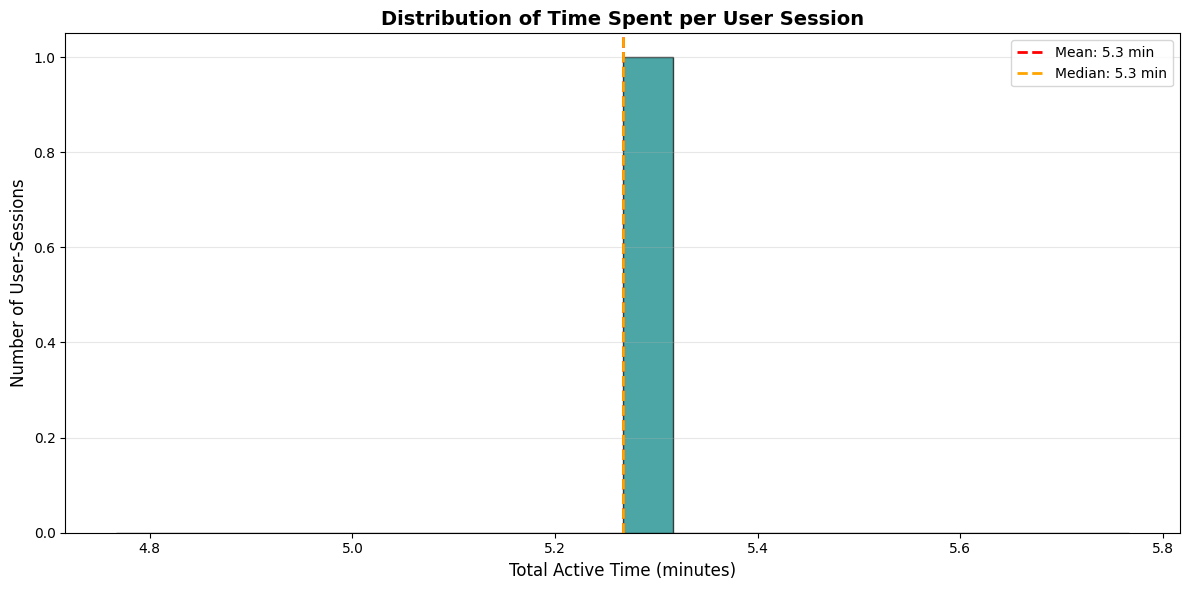


Time per user-session statistics (active time):
count    1.000000
mean     5.266667
std           NaN
min      5.266667
25%      5.266667
50%      5.266667
75%      5.266667
max      5.266667
Name: total_active_minutes, dtype: float64

Total number of user-sessions: 1


In [7]:
# Plot distribution of time spent per user
# Note: Uses time_by_user_session which aggregates total active time per user per session
if len(time_by_user_session) > 0:
    plt.figure(figsize=(12, 6))
    plt.hist(time_by_user_session['total_active_minutes'], bins=20, color='teal', edgecolor='black', alpha=0.7)
    plt.xlabel('Total Active Time (minutes)', fontsize=12)
    plt.ylabel('Number of User-Sessions', fontsize=12)
    plt.title('Distribution of Time Spent per User Session', fontsize=14, fontweight='bold')
    plt.axvline(time_by_user_session['total_active_minutes'].mean(), color='red', linestyle='--', 
                label=f"Mean: {time_by_user_session['total_active_minutes'].mean():.1f} min", linewidth=2)
    plt.axvline(time_by_user_session['total_active_minutes'].median(), color='orange', linestyle='--', 
                label=f"Median: {time_by_user_session['total_active_minutes'].median():.1f} min", linewidth=2)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nTime per user-session statistics (active time):")
    stats = time_by_user_session['total_active_minutes'].describe()
    print(stats)
    print(f"\nTotal number of user-sessions: {len(time_by_user_session)}")
else:
    print("No time data available.")


In [8]:
# Per-participant median active time across their sessions
per_user_time = (
    time_by_user_session
    .groupby('prolific_pid', dropna=False)['total_active_minutes']
    .agg(sessions='count', median_min='median', mean_min='mean', total_min='sum')
    .reset_index()
    .sort_values('median_min', ascending=False)
    .rename(columns={
        'prolific_pid': 'prolific_pid',
        'sessions':     'sessions',
        'median_min':   'median_active_min',
        'mean_min':     'mean_active_min',
        'total_min':    'total_active_min',
    })
)

print("Per-participant time summary (sorted by median active minutes):\n")
print(per_user_time.to_string(index=False))
print(f"\nOverall median across all user-sessions: "
      f"{time_by_user_session['total_active_minutes'].median():.2f} min")


Per-participant time summary (sorted by median active minutes):

 prolific_pid  sessions  median_active_min  mean_active_min  total_active_min
            3         1           5.266667         5.266667          5.266667

Overall median across all user-sessions: 5.27 min


## Attention Check Results


In [9]:
moderation_df['attention_check_passed']

0    False
1    False
2    False
3     True
4    False
5    False
6    False
7    False
Name: attention_check_passed, dtype: bool

In [10]:
# Attention check pass/fail per participant.
# A participant passes if attention_check_passed is True on their attention-check row.

# Handle is_attention_check stored as True/False strings or booleans or 1/0
attn = moderation_df[
    moderation_df['is_attention_check'].astype(str).str.strip().str.lower().isin(['true', '1'])
].copy()

print(f"Found {len(attn)} attention-check row(s)\n")

attn['passed'] = attn['attention_check_passed'].astype(str).str.strip().str.lower().isin(['true', '1'])

diag_cols = ['user_id', 'session_number', 'scenario_index', 'passed']
if not DEV_MODE and 'prolific_pid' in attn.columns:
    diag_cols[0] = 'prolific_pid'

print("Attention-check rows:\n")
print(
    attn[[c for c in diag_cols if c in attn.columns]]
    .sort_values([diag_cols[0], 'session_number', 'scenario_index'])
    .to_string(index=False)
)

total  = len(attn)
n_pass = int(attn['passed'].sum())
if total > 0:
    print(f"\nSummary: {n_pass} / {total} attention-check rows passed "
          f"({100 * n_pass / total:.1f}% pass rate)")
else:
    print("\nNo attention-check rows found.")

Found 2 attention-check row(s)

Attention-check rows:

                             user_id  session_number  scenario_index  passed
432066e5-371d-4965-8d9f-8a18e922c4f9               1               0   False
432066e5-371d-4965-8d9f-8a18e922c4f9               1               1    True

Summary: 1 / 2 attention-check rows passed (50.0% pass rate)


In [11]:
def _has_highlight(text):
    """Determine if the highlighted_texts column indicates a highlight was made."""
    if pd.isna(text) or str(text).strip() in ('', '[]'):
        return False
    try:
        items = json.loads(text)
        return isinstance(items, list) and len(items) > 0
    except json.JSONDecodeError:
        return False
attn['has_highlight'] = attn['highlighted_texts'].apply(_has_highlight)
attn['is_skip']        = ~attn['has_highlight']
attn['is_skip']

0     True
3    False
Name: is_skip, dtype: bool

In [12]:
# Re-filter all dataframes to participants × sessions where they passed the attention check.
# This keeps other sessions for a user even if they failed one session's attention check.

# Build set of (user_id, session_number) pairs that passed
_passed_pairs = set(
    attn.loc[attn['has_highlight'] == True, ['user_id', 'session_number']]
    .apply(tuple, axis=1)
)

# Also keep a flat set of user_ids that passed ANY session (for tables without session_number)
_passed_user_ids = {uid for uid, _ in _passed_pairs}

def _in_passed(df, uid_col='user_id', session_col='session_number'):
    """Filter df to rows whose (user_id, session_number) is in the passed set."""
    if session_col in df.columns:
        mask = df.apply(lambda r: (r[uid_col], r[session_col]) in _passed_pairs, axis=1)
    else:
        # Fallback: filter by user_id only (tables without session_number)
        mask = df[uid_col].isin(_passed_user_ids)
    return df[mask].copy()

moderation_df      = _in_passed(moderation_df)
child_profiles_df  = _in_passed(child_profiles_df)
exit_quiz_df       = _in_passed(exit_quiz_df, session_col='session_number')
assignment_time_df = _in_passed(assignment_time_df)
users_df           = _in_passed(users_df, uid_col='id', session_col='_none_')

print(f"Passed (user, session) pairs: {len(_passed_pairs)}")
print(f"Unique users who passed at least one session: {len(_passed_user_ids)}")
print(f"  Moderation sessions: {len(moderation_df)}")
print(f"  Child profiles:      {len(child_profiles_df)}")
print(f"  Exit quiz responses: {len(exit_quiz_df)}")
print(f"  Assignment time:     {len(assignment_time_df)}")
print(f"  Users:               {len(users_df)}")

Passed (user, session) pairs: 1
Unique users who passed at least one session: 1
  Moderation sessions: 8
  Child profiles:      1
  Exit quiz responses: 1
  Assignment time:     94
  Users:               1


## Consistency Check: Child Internet Use Frequency

Compare the `child_internet_use_frequency` field from the **child profile** with the
`childInternetUseFrequency` answer from the **exit survey** to check for consistency.

In [13]:
# ── Consistency check: child_internet_use_frequency ──────────────────────────
# Compare child-profile value vs exit-survey answer for the same question.

_id_col = 'user_id' if DEV_MODE else 'prolific_pid'

# Profile value
profile_freq = (
    child_profiles_df[child_profiles_df['is_current'].astype(str).str.strip().str.lower().isin(['true', '1'])]
    .set_index(_id_col)['child_internet_use_frequency']
    .rename('profile_value')
)

# Exit-survey value (parse JSON answers column)
def _extract_exit_freq(row):
    try:
        ans = json.loads(row['answers']) if isinstance(row['answers'], str) else row['answers']
        if isinstance(ans, dict):
            return ans.get('childInternetUseFrequency')
        if isinstance(ans, list):
            for item in ans:
                if isinstance(item, dict) and item.get('id') == 'childInternetUseFrequency':
                    return item.get('value')
    except Exception:
        pass
    return None

exit_freq = (
    exit_quiz_df[exit_quiz_df['is_current'].astype(str).str.strip().str.lower().isin(['true', '1'])]
    .assign(exit_value=lambda df: df.apply(_extract_exit_freq, axis=1))
    .set_index(_id_col)['exit_value']
    .rename('exit_value')
)

comparison = pd.concat([profile_freq, exit_freq], axis=1).dropna(how='all')
comparison['match'] = comparison['profile_value'].astype(str).str.lower() == comparison['exit_value'].astype(str).str.lower()

n_total = len(comparison)
n_match = comparison['match'].sum()
n_mismatch = n_total - n_match

print(f'Participants with both values: {n_total}')
print(f'  Matching:    {n_match}')
print(f'  Mismatched:  {n_mismatch}')
if n_mismatch > 0:
    print('\nMismatched rows:')
    display(comparison[~comparison['match']])
else:
    print('\nAll responses are consistent ✓')
display(comparison)


Participants with both values: 1
  Matching:    1
  Mismatched:  0

All responses are consistent ✓


,profile_value,exit_value,match
user_id,,,
432066e5-371d-4965-8d9f-8a18e922c4f9,4,4,True


## Skips vs Highlighted Scenarios

A **skip** is any final-version scenario where `highlighted_texts` is empty or `[]`. Attention-check scenarios are excluded.


In [14]:
# Restrict to final-version rows
moderation_df['is_highlighted'] = moderation_df['highlighted_texts'].apply(_has_highlight)
moderation_df['is_skip']        = ~moderation_df['is_highlighted']

total  = len(moderation_df)
n_highlighted = int(moderation_df['is_highlighted'].sum())
n_skipped     = int(moderation_df['is_skip'].sum())
pct_hi        = 100 * n_highlighted / total if total > 0 else 0

print("Overall scenarios:")
print(f"  Total scenarios    : {total}")
print(f"  Highlighted        : {n_highlighted}  ({pct_hi:.1f}%)")
print(f"  Skipped            : {n_skipped}  ({100 - pct_hi:.1f}%)")

Overall scenarios:
  Total scenarios    : 8
  Highlighted        : 3  (37.5%)
  Skipped            : 5  (62.5%)


In [15]:
# Per-participant breakdown of highlighted vs skipped scenarios
# Uses is_highlighted / is_skip columns set in the cell above.

group_col = 'user_id' if DEV_MODE else 'prolific_pid'

per_user_skip = (
    moderation_df.groupby(group_col, dropna=False)
    .agg(
        total=('id', 'count'),
        highlighted=('is_highlighted', 'sum'),
        skipped=('is_skip', 'sum'),
    )
    .reset_index()
)

for _c in ['total', 'highlighted', 'skipped']:
    per_user_skip[_c] = pd.to_numeric(per_user_skip[_c], errors='coerce').fillna(0)

per_user_skip['pct_highlighted'] = (
    100 * per_user_skip['highlighted'] / per_user_skip['total'].replace(0, pd.NA)
).fillna(0).round(1)

per_user_skip = per_user_skip.sort_values('pct_highlighted', ascending=False)

print("Per-participant skip vs highlight:\n")
print(per_user_skip.to_string(index=False))

Per-participant skip vs highlight:

                             user_id  total  highlighted  skipped  pct_highlighted
432066e5-371d-4965-8d9f-8a18e922c4f9      8            3        5             37.5


KeyError: 'prolific_pid'

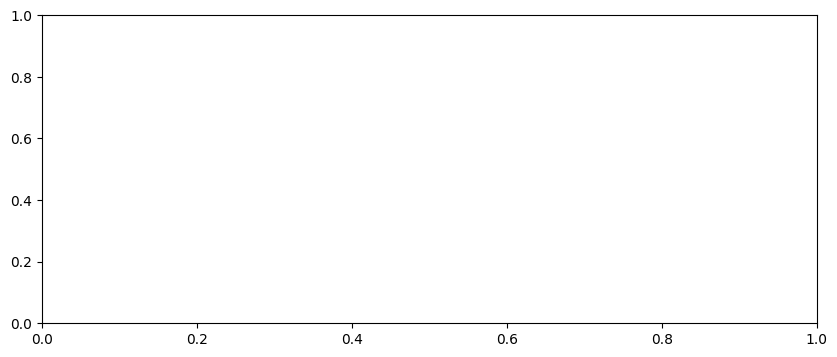

In [16]:
# Stacked horizontal bar chart — highlighted (green) vs skipped (gray) per participant
#_sorted = per_user_skip.sort_values('pct_highlighted', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(per_user_skip) * 0.5 + 1.5)))

pids    = per_user_skip['prolific_pid'].fillna('(no pid)').astype(str).tolist()
hi_vals = per_user_skip['highlighted'].tolist()
sk_vals = per_user_skip['skipped'].tolist()
y_pos   = list(range(len(pids)))

ax.barh(y_pos, hi_vals,              color='#4caf50', label='Highlighted', alpha=0.85)
ax.barh(y_pos, sk_vals, left=hi_vals, color='#bdbdbd', label='Skipped',    alpha=0.85)

# Annotate pct highlighted at the right edge of each bar
for i, (row) in enumerate(per_user_skip.itertuples()):
    ax.text(
        row.total + 0.1, i,
        f"{row.pct_highlighted:.0f}%",
        va='center', fontsize=8, color='#333',
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(pids, fontsize=9)
ax.set_xlabel('Number of Final Scenarios')
ax.set_title('Highlighted vs Skipped Scenarios per Participant', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Exit Survey Summary

Frequency counts for each survey question, with median highlight count per participant shown alongside each response category so you can see whether a demographic trait correlates with highlighting behaviour.


In [17]:
import json
import pandas as pd

# ── Exit Survey Summary ──────────────────────────────────────────────────────
# Parse the JSON `answers` blob into flat columns, then summarise each question.
# For each category value we show: count of participants AND their median
# highlight count.


# 1. Parse answers JSON
eq = exit_quiz_df.copy()
eq['_answers'] = eq['answers'].apply(
    lambda x: json.loads(x) if pd.notna(x) and str(x).strip() else {}
)

def _as_scalar(v):
    # Keep true scalars as-is; unwrap simple one-item lists; stringify complex values
    if isinstance(v, list):
        if len(v) == 0:
            return pd.NA
        if len(v) == 1:
            return v[0]
        return " | ".join(map(str, v))
    if isinstance(v, dict):
        return json.dumps(v, sort_keys=True)
    return v

def _as_list(v):
    if isinstance(v, list):
        return v
    if pd.isna(v):
        return []
    # If value is a JSON-encoded list string, parse it
    if isinstance(v, str):
        s = v.strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = json.loads(s)
                return parsed if isinstance(parsed, list) else [str(v)]
            except Exception:
                pass
    return [v]

# Flatten scalar answer fields into columns
SCALAR_FIELDS = [
    'parentGender', 'parentAge', 'areaOfResidency', 'parentEducation',
    'genaiFamiliarity', 'genaiUsageFrequency', 'parentingStyle',
    'isOnlyChild', 'childHasAIUse', 'parentLLMMonitoringLevel',
    'parentInternetUseFrequency', 'childInternetUseFrequency',
]
for f in SCALAR_FIELDS:
    eq[f] = eq['_answers'].apply(lambda d: _as_scalar(d.get(f)))

# Multi-select list fields
MULTI_FIELDS = ['parentEthnicity', 'childAIUseContexts', 'childPersonalitySubCharacteristics']
for f in MULTI_FIELDS:
    eq[f] = eq['_answers'].apply(lambda d: _as_list(d.get(f, [])))

# 2. Compute per-participant highlight count from moderation table
_src = moderation_df_filtered.copy() if 'moderation_df_filtered' in globals() else moderation_df.copy()
_hi_counts = _src[_src['is_attention_check'] != 1].copy()
_hi_counts['has_highlight'] = _hi_counts['highlighted_texts'].apply(_has_highlight)

highlights_per_user = (
    _hi_counts.groupby('user_id', dropna=False)['has_highlight']
    .sum()
    .reset_index()
    .rename(columns={'has_highlight': 'n_highlights'})
)

# Join highlight counts onto the exit-quiz table
eq = eq.merge(highlights_per_user, on='user_id', how='left')
eq['n_highlights'] = eq['n_highlights'].fillna(0).astype(int)

print(f"Exit survey rows: {len(eq)}")
print(f"Highlight counts attached: {eq['n_highlights'].tolist()}")

def _to_hashable(v):
    if isinstance(v, list):
        return tuple(v)
    if isinstance(v, dict):
        return json.dumps(v, sort_keys=True)
    return v

# 3. Helper: summarise a single-value column
def _summarise_single(col_name, label=None):
    label = label or col_name

    tmp = eq[[col_name, 'user_id', 'n_highlights']].copy()
    tmp['value'] = tmp[col_name].apply(_to_hashable)
    tmp['value'] = tmp['value'].where(tmp['value'].notna(), '(missing)')

    grp = (
        tmp.groupby('value', dropna=False)
        .agg(
            count=('user_id', 'count'),
            median_highlights=('n_highlights', 'median'),
            mean_highlights=('n_highlights', 'mean'),
        )
        .reset_index()
        .sort_values('count', ascending=False)
    )
    grp['median_highlights'] = grp['median_highlights'].round(1)
    grp['mean_highlights'] = grp['mean_highlights'].round(1)

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(grp[['value', 'count', 'median_highlights', 'mean_highlights']].to_string(index=False))

# 4. Helper: summarise a multi-select (list) column
def _summarise_multi(col_name, label=None):
    label = label or col_name
    _rows = []
    for _, r in eq.iterrows():
        vals = _as_list(r[col_name])
        if len(vals) == 0:
            _rows.append({'value': '(none)', 'n_highlights': r['n_highlights']})
        else:
            for v in vals:
                _rows.append({'value': _to_hashable(v), 'n_highlights': r['n_highlights']})

    _exp = pd.DataFrame(_rows)
    grp = (
        _exp.groupby('value', dropna=False)
        .agg(
            count=('n_highlights', 'count'),
            median_highlights=('n_highlights', 'median'),
            mean_highlights=('n_highlights', 'mean'),
        )
        .reset_index()
        .sort_values('count', ascending=False)
    )
    grp['median_highlights'] = grp['median_highlights'].round(1)
    grp['mean_highlights'] = grp['mean_highlights'].round(1)

    print(f"\n{'='*60}")
    print(f"  {label}  [multi-select — counts are participant×option]")
    print(f"{'='*60}")
    print(grp[['value', 'count', 'median_highlights', 'mean_highlights']].to_string(index=False))

# ── Demographic questions ────────────────────────────────────────────────────
_summarise_single('parentGender',              'Parent Gender')
_summarise_single('parentAge',                 'Parent Age Group')
_summarise_single('areaOfResidency',           'Area of Residency')
_summarise_single('parentEducation',           'Parent Education Level')
_summarise_multi ('parentEthnicity',           'Parent Ethnicity (multi-select)')

# ── GenAI familiarity ────────────────────────────────────────────────────────
_summarise_single('genaiFamiliarity',          'GenAI Familiarity')
_summarise_single('genaiUsageFrequency',       'GenAI Usage Frequency')
_summarise_single('parentInternetUseFrequency','Parent Internet Use Frequency (1-10)')

# ── Parenting & child AI use ─────────────────────────────────────────────────
_summarise_single('parentingStyle',            'Parenting Style')
_summarise_single('isOnlyChild',               'Is Only Child')
_summarise_single('childHasAIUse',             'Child Has AI Use')
_summarise_multi ('childAIUseContexts',        'Child AI Use Contexts (multi-select)')
_summarise_single('parentLLMMonitoringLevel',  'Parent LLM Monitoring Level')
_summarise_single('childInternetUseFrequency', 'Child Internet Use Frequency (1-10)')

# ── Overall highlight summary ────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  Highlights per participant (summary)")
print(f"{'='*60}")
print(eq[['prolific_pid', 'n_highlights']].to_string(index=False))
print(f"\nMean highlights: {eq['n_highlights'].mean():.1f}")
print(f"Median highlights: {eq['n_highlights'].median():.1f}")


Exit survey rows: 1
Highlight counts attached: [2]

  Parent Gender
 value  count  median_highlights  mean_highlights
female      1                2.0              2.0

  Parent Age Group
value  count  median_highlights  mean_highlights
55-64      1                2.0              2.0

  Area of Residency
value  count  median_highlights  mean_highlights
rural      1                2.0              2.0

  Parent Education Level
     value  count  median_highlights  mean_highlights
associates      1                2.0              2.0

  Parent Ethnicity (multi-select)  [multi-select — counts are participant×option]
          value  count  median_highlights  mean_highlights
          asian      1                2.0              2.0
hispanic-latino      1                2.0              2.0

  GenAI Familiarity
          value  count  median_highlights  mean_highlights
tried_few_times      1                2.0              2.0

  GenAI Usage Frequency
          value  count  median_highli

## Highlights by Scenario Characteristics

For each scenario-level characteristic (`trait`, `polarity`, `prompt_style`, `domain`, `age_band`, `trait_level`) show median and mean highlight counts — so you can see which kinds of scenarios attract more concern.

Below that, a cross-tab shows the same breakdown split by parent demographic, making it easy to spot whether a particular parent trait drives the difference.


In [18]:

# ── Load scenarios CSV ───────────────────────────────────────────────────────
_scenarios_file = f'scenarios_export_{EXPORT_TIMESTAMP}.csv'
if os.path.exists(_scenarios_file):
    scenarios_df = pd.read_csv(_scenarios_file)
    print(f"Loaded {len(scenarios_df)} scenarios.")
else:
    print(f"WARNING: {_scenarios_file} not found. Re-run the export script to get it.")
    scenarios_df = pd.DataFrame()

# ── Join moderation rows to scenario metadata ────────────────────────────────
# moderation_df has a scenario_id column (populated by the export script).
# We join on that; rows without a match still appear (scenario cols will be NaN).
_mod = moderation_df[moderation_df['is_attention_check'] != 1].copy()
_mod['has_highlight'] = _mod['highlighted_texts'].apply(_has_highlight)

if not scenarios_df.empty and 'scenario_id' in _mod.columns:
    _joined = _mod.merge(
        scenarios_df[['scenario_id', 'trait', 'polarity', 'prompt_style',
                      'domain', 'subdomain', 'age_band', 'trait_level']],
        on='scenario_id',
        how='left',
    )
else:
    _joined = _mod.copy()
    for _c in ['trait', 'polarity', 'prompt_style', 'domain',
               'subdomain', 'age_band', 'trait_level']:
        if _c not in _joined.columns:
            _joined[_c] = pd.NA

print(f"Joined rows: {len(_joined)}  |  "
      f"matched to scenario: {_joined['trait'].notna().sum()}")

# ── Per-scenario highlight counts (one row per moderation session) ────────────
# Aggregate so each (user, scenario_id) counts once — use the last saved row.
_deduped = (
    _joined
    .sort_values(['user_id', 'scenario_id', 'updated_at'], na_position='first')
    .groupby(['user_id', 'prolific_pid', 'scenario_id',
              'trait', 'polarity', 'prompt_style',
              'domain', 'subdomain', 'age_band', 'trait_level'],
             dropna=False)
    .agg(highlighted=('has_highlight', 'max'))
    .reset_index()
)

# ── Helper: summarise a scenario characteristic column ───────────────────────
SCENARIO_CHARS = [
    ('trait',        'Trait (Big-Five dimension)'),
    ('polarity',     'Polarity (positive/negative/neutral)'),
    ('prompt_style', 'Prompt Style'),
    ('domain',       'Domain'),
    ('subdomain',    'Subdomain'),
    ('age_band',     'Age Band'),
    ('trait_level',  'Trait Level (high/low)'),
]

def _scenario_summary(col, label):
    grp = (
        _deduped.groupby(col, dropna=False)
        .agg(
            n_scenarios=('scenario_id', 'nunique'),
            n_user_sessions=('user_id', 'count'),
            n_highlighted=('highlighted', 'sum'),
            median_highlighted=('highlighted', 'median'),
            mean_highlighted=('highlighted', 'mean'),
        )
        .reset_index()
        .rename(columns={col: 'value'})
        .sort_values('n_user_sessions', ascending=False)
    )
    grp['pct_highlighted'] = (
        100 * grp['n_highlighted'] / grp['n_user_sessions'].replace(0, pd.NA)
    ).fillna(0).round(1)
    grp['mean_highlighted'] = grp['mean_highlighted'].round(2)
    print(f"\n{'='*70}")
    print(f"  {label}")
    print(f"{'='*70}")
    print(grp[['value', 'n_scenarios', 'n_user_sessions',
               'n_highlighted', 'pct_highlighted']].to_string(index=False))

for _col, _lbl in SCENARIO_CHARS:
    if _col in _deduped.columns:
        _scenario_summary(_col, _lbl)

# # ── Cross-tab: parent characteristic × scenario characteristic ───────────────
# # Use 'eq' from the Exit Survey section (contains per-parent data + n_highlights).
# # We join parent demographic back to the per-scenario data.

# print(f"\n\n{'#'*70}")
# print("  CROSS-TAB: Parent Characteristic × Scenario Characteristic")
# print(f"{'#'*70}")

# # Build a per-(user, scenario) table with parent demographics attached
# _parent_cols = [
#     ('parentAge',                'Parent Age',          False),
#     ('genaiFamiliarity',         'GenAI Familiarity',   False),
#     ('genaiUsageFrequency',      'GenAI Usage Freq',    False),
#     ('parentLLMMonitoringLevel', 'Parent LLM Monitor',  False),
#     ('parentEthnicity',          'Parent Ethnicity',    True),   # multi-select
#     ('childHasAIUse',            'Child Has AI Use',    False),
# ]

# # eq is defined in the Exit Survey cell — guard in case cell order differs
# if 'eq' not in dir() and 'eq' not in globals():
#     print("WARNING: 'eq' (exit quiz DataFrame) not found. "
#           "Run the Exit Survey Summary cell first.")
# else:
#     # Flatten parent demographics for the join (use scalar fields; explode multi-selects)
#     _eq_slim = eq[['user_id'] + [c for c, _, _ in _parent_cols]].copy()

#     for _pc, _plbl, _is_multi in _parent_cols:
#         if _pc not in _eq_slim.columns:
#             continue
#         _sub = _deduped.merge(_eq_slim[['user_id', _pc]], on='user_id', how='left')
#         unique_parents = _sub['user_id'].nunique()
#         print(f"\n{'─'*70}")
#         print(f"  Parent: {_plbl}  ×  Scenario characteristics  "
#               f"(n={unique_parents} participants)")
#         print(f"{'─'*70}")

#         for _sc, _slbl in SCENARIO_CHARS:
#             if _sc not in _sub.columns:
#                 continue
#             if _is_multi:
#                 # Explode comma-separated parent values before grouping
#                 _exploded = []
#                 for _, r in _sub.iterrows():
#                     pvals = r[_pc] if isinstance(r[_pc], list) else (
#                         [] if pd.isna(r[_pc]) else [r[_pc]]
#                     )
#                     if not pvals:
#                         pvals = ['(none)']
#                     for pv in pvals:
#                         _exploded.append({
#                             'parent_val':  str(pv),
#                             'scenario_val': str(r[_sc]) if pd.notna(r[_sc]) else '(unknown)',
#                             'highlighted': r['highlighted'],
#                         })
#                 _ct = pd.DataFrame(_exploded)
#             else:
#                 _ct = _sub[[_pc, _sc, 'highlighted']].copy()
#                 _ct = _ct.rename(columns={_pc: 'parent_val', _sc: 'scenario_val'})
#                 _ct['parent_val']   = _ct['parent_val'].fillna('(missing)').astype(str)
#                 _ct['scenario_val'] = _ct['scenario_val'].fillna('(unknown)').astype(str)

#             if _ct.empty:
#                 continue

#             _pivot = (
#                 _ct.groupby(['scenario_val', 'parent_val'])
#                 .agg(n=('highlighted', 'count'), pct_hi=('highlighted', 'mean'))
#                 .reset_index()
#             )
#             _pivot['pct_hi'] = (_pivot['pct_hi'] * 100).round(1)
#             _pivot_wide = _pivot.pivot(
#                 index='scenario_val', columns='parent_val', values='pct_hi'
#             ).fillna(0).round(1)

#             print(f"\n  {_slbl}  — % of sessions highlighted  (rows = scenario value, cols = parent value)")
#             print(_pivot_wide.to_string())


Loaded 50 scenarios.
Joined rows: 6  |  matched to scenario: 6

  Trait (Big-Five dimension)
        value  n_scenarios  n_user_sessions  n_highlighted  pct_highlighted
     Openness            3                3              1             33.3
Agreeableness            1                1              0              0.0
 Extraversion            1                1              0              0.0
  Neuroticism            1                1              1            100.0

  Polarity (positive/negative/neutral)
 value  n_scenarios  n_user_sessions  n_highlighted  pct_highlighted
   NaN            6                6              2             33.3

  Prompt Style
 value  n_scenarios  n_user_sessions  n_highlighted  pct_highlighted
   NaN            6                6              2             33.3

  Domain
                  value  n_scenarios  n_user_sessions  n_highlighted  pct_highlighted
Casual Knowledge Domain            4                4              1             25.0
        Acade

## Highlight Replay Tool

Select a participant and scenario index to see the original AI response with their highlights applied — replicating the webapp view.


In [19]:
def _parse_highlights(raw):
    """Parse highlights from the CSV (JSON string, list, or None) → list."""
    if isinstance(raw, list):
        return raw
    if pd.isna(raw):
        return []
    s = str(raw).strip()
    if not s or s == '[]':
        return []
    try:
        parsed = json.loads(s)
        return parsed if isinstance(parsed, list) else [parsed]
    except Exception:
        return [s]


def render_highlighted_scenario(text, highlights, concern_items=None):
    """Render *text* with *highlights* applied as <mark> spans."""
    text = '' if text is None else str(text)
    highlights = _parse_highlights(highlights) if not isinstance(highlights, list) else highlights

    ranges = []

    for h in highlights:
        if isinstance(h, dict):
            a = h.get('start', h.get('start_offset', h.get('start_idx', h.get('from'))))
            b = h.get('end',   h.get('end_offset',   h.get('end_idx',   h.get('to'))))
            if a is not None and b is not None:
                try:
                    a, b = int(a), int(b)
                    if a < b and 0 <= a < len(text):
                        ranges.append((a, min(b, len(text))))
                except Exception:
                    pass
            h_text = h.get('text', '')
            if h_text and not ranges:
                pos = 0
                while True:
                    i = text.find(h_text, pos)
                    if i == -1:
                        break
                    ranges.append((i, i + len(h_text)))
                    pos = i + len(h_text)

    for h in highlights:
        if isinstance(h, str) and h:
            pos = 0
            while True:
                i = text.find(h, pos)
                if i == -1:
                    break
                ranges.append((i, i + len(h)))
                pos = i + len(h)

    if concern_items:
        for ci in concern_items:
            linked = ci.get('linked_highlights', '[]')
            if isinstance(linked, str):
                try:
                    linked = json.loads(linked)
                except Exception:
                    linked = []
            if isinstance(linked, list):
                for lh in linked:
                    if isinstance(lh, str) and lh:
                        pos = 0
                        while True:
                            i = text.find(lh, pos)
                            if i == -1:
                                break
                            ranges.append((i, i + len(lh)))
                            pos = i + len(lh)

    if not ranges:
        return (
            "<pre style='white-space:pre-wrap;line-height:1.6;"
            "font-family:inherit;margin:0'>"
            f"{escape(text)}</pre>"
        )

    ranges.sort()
    merged = []
    for a, b in ranges:
        if not merged or a > merged[-1][1]:
            merged.append([a, b])
        else:
            merged[-1][1] = max(merged[-1][1], b)

    parts, last = [], 0
    for a, b in merged:
        if last < a:
            parts.append(escape(text[last:a]))
        parts.append(
            f"<mark style='background:#fff59d;padding:0 2px'>"
            f"{escape(text[a:b])}</mark>"
        )
        last = b
    if last < len(text):
        parts.append(escape(text[last:]))

    return (
        "<pre style='white-space:pre-wrap;line-height:1.6;"
        "font-family:inherit;margin:0'>"
        + ''.join(parts)
        + "</pre>"
    )

In [ ]:
# Interactive highlight replay
# Shows the scenario prompt and the original AI response with the user's highlights applied.
# Also shows linked concern items from the concern_items table.

_replay_df = moderation_df[
    ~moderation_df['is_attention_check'].astype(str).str.strip().str.lower().isin(['true', '1'])
].copy()

_id_col = 'user_id' if DEV_MODE else 'prolific_pid'
_pid_opts = sorted(_replay_df[_id_col].dropna().unique().tolist())

pid_dd = widgets.Dropdown(
    options     = _pid_opts,
    value       = _pid_opts[0] if _pid_opts else None,
    description = 'Participant:',
    style       = {'description_width': '90px'},
    layout      = widgets.Layout(width='440px'),
)

scenario_dd = widgets.Dropdown(
    options     = [],
    description = 'Scenario:',
    style       = {'description_width': '90px'},
    layout      = widgets.Layout(width='440px'),
)

out = widgets.Output()


def _refresh_scenarios(change=None):
    pid = pid_dd.value
    if pid is None:
        scenario_dd.options = []
        return
    sub = _replay_df[_replay_df[_id_col] == pid]
    # Build (scenario_id, scenario_index) pairs for display
    pairs = (
        sub[['scenario_id', 'scenario_index']]
        .dropna(subset=['scenario_id'])
        .drop_duplicates('scenario_id')
        .sort_values('scenario_index')
    )
    opts = [(f"#{int(r.scenario_index)} — {r.scenario_id}", r.scenario_id) for _, r in pairs.iterrows()]
    scenario_dd.options = opts
    if opts:
        scenario_dd.value = opts[0][1]


def _get_concern_items_for_row(row):
    """Get concern items matching this moderation session row."""
    if concern_items_df.empty:
        return []
    mask = (concern_items_df['user_id'] == row.get('user_id'))
    if 'scenario_id' in concern_items_df.columns:
        mask = mask & (concern_items_df['scenario_id'] == row.get('scenario_id'))
    if 'session_number' in concern_items_df.columns:
        mask = mask & (concern_items_df['session_number'].astype(str) == str(row.get('session_number', '')))
    return concern_items_df[mask].to_dict('records')


def _render(change=None):
    out.clear_output(wait=True)
    pid = pid_dd.value
    sid = scenario_dd.value  # scenario_id
    if pid is None or sid is None:
        return

    subset = _replay_df[
        (_replay_df[_id_col] == pid) &
        (_replay_df['scenario_id'] == sid)
    ]
    if subset.empty:
        with out:
            print("No data for this selection.")
        return

    row        = subset.iloc[-1]
    prompt     = str(row.get('scenario_prompt') or '')
    response   = str(row.get('original_response') or '')
    highlights = row.get('highlighted_texts', '[]')
    decision   = row.get('initial_decision',  '—')
    concern    = row.get('concern_level',      '—')
    reason     = str(row.get('concern_reason', '') or '')
    sc_index   = row.get('scenario_index', '—')

    ci_list = _get_concern_items_for_row(row)

    ci_html = ''
    if ci_list:
        ci_parts = []
        for ci in ci_list:
            ci_text = escape(str(ci.get('text', '')))
            ci_level = ci.get('concern_level', '—')
            linked = ci.get('linked_highlights', '[]')
            if isinstance(linked, str):
                try:
                    linked = json.loads(linked)
                except Exception:
                    linked = []
            linked_str = ', '.join(f'"{escape(str(h))}"' for h in linked) if linked else 'none'
            ci_parts.append(
                f"<li><b>{ci_text}</b> (level: {ci_level}) — highlights: {linked_str}</li>"
            )
        ci_html = (
            "<div style='margin-top:12px;border-top:1px solid #ddd;padding-top:8px'>"
            "<div style='font-family:sans-serif;font-size:12px;font-weight:bold;"
            "color:#555;margin-bottom:4px;text-transform:uppercase;letter-spacing:.05em'>"
            "Concern Items</div>"
            f"<ul style='margin:4px 0;padding-left:20px;font-size:13px'>{''.join(ci_parts)}</ul>"
            "</div>"
        )

    reason_html = (
        f"<br><b>Concern reason:</b> {escape(reason)}"
        if reason and reason != 'nan' else ''
    )
    header = (
        "<div style='font-family:sans-serif;font-size:13px;"
        "border-bottom:1px solid #ddd;padding-bottom:6px;margin-bottom:8px'>"
        f"<b>Participant:</b> {escape(str(pid))} &nbsp;|&nbsp; "
        f"<b>Scenario:</b> #{sc_index} ({escape(str(sid))}) &nbsp;|&nbsp; "
        f"<b>Decision:</b> {escape(str(decision))} &nbsp;|&nbsp; "
        f"<b>Concern level:</b> {escape(str(concern))}"
        f"{reason_html}"
        "</div>"
    )

    prompt_section = ""
    if prompt:
        prompt_section = (
            "<div style='margin-bottom:12px'>"
            "<div style='font-family:sans-serif;font-size:12px;font-weight:bold;"
            "color:#555;margin-bottom:4px;text-transform:uppercase;letter-spacing:.05em'>"
            "Scenario Prompt</div>"
            + render_highlighted_scenario(prompt, [])
            + "</div>"
        )

    response_section = ""
    if response:
        response_section = (
            "<div>"
            "<div style='font-family:sans-serif;font-size:12px;font-weight:bold;"
            "color:#555;margin-bottom:4px;text-transform:uppercase;letter-spacing:.05em'>"
            "AI Response (with highlights)</div>"
            + render_highlighted_scenario(response, highlights, concern_items=ci_list)
            + "</div>"
        )

    with out:
        display(HTML(
            "<div style='border:1px solid #e0e0e0;border-radius:4px;"
            "padding:12px;font-size:13px'>"
            + header + prompt_section + response_section + ci_html +
            "</div>"
        ))


pid_dd.observe(_refresh_scenarios, names='value')
pid_dd.observe(_render,            names='value')
scenario_dd.observe(_render,       names='value')

_refresh_scenarios()
_render()

display(widgets.VBox([
    widgets.HBox([pid_dd, scenario_dd]),
    out,
]))